# Trabajo Práctico Integrador: Hitos 1 y 2
**Integrantes del grupo:**
1. Nicolas Llaneza
2. David Lopez
3. Sabrina Moreira
4. Tomas Ferro
5. Emmanuel Avellaneda

---

### Dataset Elegido

**Nombre:** `Students Performance Dataset.csv`  
**Fuente:** Kaggle

---

### Preguntas de Negocio / Pedagógicas

#### Pregunta 1 — Predicción de Riesgo de Abandono
> **¿Qué combinación de variables conductuales y académicas (asistencia, nivel de estrés, horas de estudio y nota del parcial) permite identificar, con mayor precisión, a los estudiantes con alta probabilidad de obtener una calificación final reprobatoria (F) antes de que finalice el cursado?**

**Hipótesis:** Estudiantes con asistencia inferior al 65 %, nota de parcial inferior a 50 y nivel de estrés superior a 7 concentran la mayor parte de las reprobaciones finales, independientemente del departamento académico.

#### Pregunta 2 — Eficiencia del Esfuerzo Académico
> **¿Existe una relación no lineal entre las horas semanales de estudio y el rendimiento académico final, y en qué punto el incremento de horas deja de producir mejoras significativas en la nota total (rendimiento marginal decreciente)?**

**Hipótesis:** A partir de las 20 horas semanales el incremento en `Total_Score` se estabiliza, y los estudiantes con alto estrés no obtienen beneficio adicional aunque aumenten sus horas de estudio.

#### Pregunta 3 — Brecha de Equidad por Contexto Socioeconómico
> **¿En qué medida el nivel de ingresos familiar y el acceso a Internet en el hogar condicionan el desempeño académico, y qué departamentos presentan mayor dispersión de resultados asociada a esas variables de contexto?**

**Hipótesis:** Estudiantes de bajos ingresos sin acceso a Internet en el hogar muestran un promedio de `Total_Score` significativamente inferior al grupo de altos ingresos con acceso, siendo la brecha más pronunciada en departamentos con alta carga de trabajo autónomo

---

### Paso 0 — Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
print('Librerías importadas correctamente')

Librerías importadas correctamente


### Paso 1 — Carga del Dataset


In [ ]:
url = "https://raw.githubusercontent.com/Sabrinavmr/TPI-Analisis-Datos/refs/heads/main/Students_Grading_Dataset_Biased.csv"

df = pd.read_csv(url)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (5000, 23)


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,NaN,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [ ]:
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

if df.shape[0] >= 5000:
    print("El dataset cumple con el requisito mínimo de 5000 registros.")
else:
    print("El dataset NO cumple con el requisito mínimo requerido.")

Cantidad de filas: 5000
Cantidad de columnas: 23
El dataset cumple con el requisito mínimo de 5000 registros.


### Paso 2 — Auditoría Inicial del Dataset

In [ ]:
print('── Tipos de datos ──────────────────────────')
print(df.dtypes)
print()
print('── Estadísticas descriptivas ───────────────')
df.describe().round(2)

── Tipos de datos ──────────────────────────
Student_ID                     object
First_Name                     object
Last_Name                      object
Email                          object
Gender                         object
Age                             int64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                          object
Study_Hours_per_Week          float64
Extracurricular_Activities     object
Internet_Access_at_Home        object
Parent_Education_Level         object
Family_Income_Level            object
Stress_Level (1-10)             int64
Sleep_Hours_per_Night         float64
dtype: object

── Estadísticas descriptivas ───────────────


,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.00,4484.00,5000.00,5000.00,4483.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,21.05,75.43,70.33,69.64,74.80,74.91,4.98,74.92,75.12,17.66,5.48,6.49
std,1.99,14.37,17.21,17.24,14.41,14.50,2.89,14.42,14.40,7.28,2.86,1.45
min,18.00,50.01,40.00,40.00,50.00,50.03,0.00,50.01,50.02,5.00,1.00,4.00
25%,19.00,63.26,55.46,54.67,62.09,62.49,2.44,62.32,62.84,11.40,3.00,5.20
50%,21.00,75.72,70.51,69.74,74.81,74.69,4.96,74.98,75.40,17.50,5.00,6.50
75%,23.00,87.47,84.97,84.50,86.97,87.63,7.50,87.37,87.65,24.10,8.00,7.70
max,24.00,100.00,99.98,99.98,99.98,99.96,10.00,100.00,99.99,30.00,10.00,9.00


In [ ]:
print('── Valores nulos por columna ───────────────')
nulos = df.isnull().sum()
display(nulos[nulos > 0].rename('Nulos').to_frame())
print(f'Total de nulos: {nulos.sum()}')

# ── Detección y tratamiento de duplicados
n_dup = df.duplicated().sum()
print(f'\nFilas duplicadas detectadas: {n_dup}')

if n_dup > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Se eliminaron {n_dup} filas duplicadas. Dataset: {len(df):,} registros.')
else:
    print('No se detectaron duplicados. No se requiere acción.')

── Valores nulos por columna ───────────────


,Nulos
Attendance (%),516
Assignments_Avg,517
Parent_Education_Level,1794


Total de nulos: 2827

Filas duplicadas detectadas: 0
No se detectaron duplicados. No se requiere acción.


### Paso 3 — Tratamiento de Valores Nulos

La única columna con valores nulos es `Parent_Education_Level` (≈ 20 % del dataset).  
**Criterio adoptado:** imputación con la categoría `'Unknown'` porque no es válido asumir el nivel educativo de los padres de ningún estudiante, y eliminar esos registros introduciría sesgo en el análisis de equidad.

**ARREGLOS**

Se detectaron tres columnas con valores faltantes:

| Columna | Nulos | Tipo | Criterio de imputación |
|---|---|---|---|
| `Parent_Education_Level` | ~1033 | Categórica | Categoría `'Unknown'` — no es válido asumir el nivel educativo |
| `Attendance (%)` | ~516 | Numérica | **Mediana** — robusta ante asimetrías, evita sesgar el análisis de asistencia |
| `Assignments_Avg` | ~517 | Numérica | **Mediana** — misma justificación; la media se vería distorsionada por valores extremos |

Se usa la **mediana** para las variables numéricas porque es una medida de tendencia central robusta que no se ve afectada por valores atípicos (outliers), a diferencia de la media.

In [ ]:
# ── 1. Variable categórica: imputar con categoría 'Unknown'
df['Parent_Education_Level'] = df['Parent_Education_Level'].fillna('Unknown')

# ── 2. Variables numéricas: imputar con la mediana (robusta ante outliers)
cols_numericas_con_nulos = ['Attendance (%)', 'Assignments_Avg']

for col in cols_numericas_con_nulos:
    mediana = df[col].median()
    nulos_antes = df[col].isnull().sum()
    df[col] = df[col].fillna(mediana)
    print(f'  {col}: {nulos_antes} nulos imputados con mediana = {mediana:.2f}')

# ── Control de calidad: verificar dataset 100% limpio
assert df.isnull().sum().sum() == 0, '❌ Aún quedan valores nulos en el dataset.'
print(f'\n✅ Nulos restantes: {df.isnull().sum().sum()} — Dataset 100% limpio.')

  Attendance (%): 516 nulos imputados con mediana = 75.72
  Assignments_Avg: 517 nulos imputados con mediana = 74.81

✅ Nulos restantes: 0 — Dataset 100% limpio.


### Paso 4 — Normalización de Strings


In [ ]:
cols_categoricas = [
    'Gender', 'Department', 'Extracurricular_Activities',
    'Internet_Access_at_Home', 'Parent_Education_Level',
    'Family_Income_Level', 'Grade'
]

for col in cols_categoricas:
    df[col] = df[col].str.strip().str.title()

print('Strings normalizados (strip + title case)\n')

for col in ['Gender', 'Grade', 'Family_Income_Level', 'Department']:
    print(f'{col:30s}: {sorted(df[col].unique())}')

Strings normalizados (strip + title case)

Gender                        : ['Female', 'Male']
Grade                         : ['A', 'B', 'C', 'D', 'F']
Family_Income_Level           : ['High', 'Low', 'Medium']
Department                    : ['Business', 'Cs', 'Engineering', 'Mathematics']


### Paso 5 — Detección y Eliminación de Outliers (Método IQR)

Se aplica el método del **Rango Intercuartílico (IQR)** sobre las 10 variables numéricas del dataset.

**Fórmula de los límites:**
- Límite inferior: Q1 − 1.5 × IQR
- Límite superior: Q3 + 1.5 × IQR


In [ ]:
cols_numericas = [
    'Attendance (%)', 'Midterm_Score', 'Final_Score',
    'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
    'Projects_Score', 'Total_Score', 'Study_Hours_per_Week',
    'Sleep_Hours_per_Night'
]

filas_antes = len(df)
mascara_outliers = pd.Series([False] * len(df), index=df.index)

print(f'{'Variable':<30} {'Q1':>7} {'Q3':>7} {'IQR':>7} {'Lím.Inf':>9} {'Lím.Sup':>9} {'CV%':>6} {'Outliers':>9}')
print('-' * 90)

for col in cols_numericas:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_col = (df[col] < lower) | (df[col] > upper)
    cantidad = outliers_col.sum()
    # Coeficiente de variación: cuánto dispersa la variable en relación a su media
    cv = (df[col].std() / df[col].mean() * 100) if df[col].mean() != 0 else 0
    alerta = '  ⚠️ límites muy amplios' if IQR > (df[col].max() - df[col].min()) * 0.6 else ''
    print(f'{col:<30} {Q1:>7.2f} {Q3:>7.2f} {IQR:>7.2f} {lower:>9.2f} {upper:>9.2f} {cv:>5.1f}% {cantidad:>8}{alerta}')
    mascara_outliers = mascara_outliers | outliers_col

print('-' * 90)

df = df[~mascara_outliers].reset_index(drop=True)

eliminados = filas_antes - len(df)
print(f'\nFilas eliminadas por outliers : {eliminados}')
print(f'Dataset resultante            : {len(df):,} registros')

if eliminados == 0:
    print()
    print('ℹ️  0 outliers detectados. Interpretación:')
    print('   Al ser datos simulados con distribución uniforme, el IQR estándar (×1.5)')
    print('   puede resultar holgado. Si el CV de alguna variable es bajo (<15%),')
    print('   confirma que los datos son homogéneos y la ausencia de outliers es esperable.')
    print('   Para Hito 3: evaluar si un factor multiplicador más estricto (×1.0 o ×1.25)')
    print('   detecta casos extremos relevantes para el análisis de riesgo académico.')


Variable                            Q1      Q3     IQR   Lím.Inf   Lím.Sup    CV%  Outliers
------------------------------------------------------------------------------------------
Attendance (%)                   64.74   86.18   21.45     32.57    118.35  18.0%        0
Midterm_Score                    55.46   84.97   29.51     11.19    129.24  24.5%        0
Final_Score                      54.67   84.50   29.83      9.92    129.25  24.8%        0
Assignments_Avg                  63.69   85.57   21.88     30.86    118.39  18.2%        0
Quizzes_Avg                      62.49   87.63   25.14     24.78    125.34  19.4%        0
Participation_Score               2.44    7.50    5.06     -5.15     15.09  58.0%        0
Projects_Score                   62.32   87.37   25.05     24.75    124.94  19.3%        0
Total_Score                      62.84   87.65   24.82     25.61    124.88  19.2%        0
Study_Hours_per_Week             11.40   24.10   12.70     -7.65     43.15  41.2%        

### Paso 6 — Feature Engineering: Creación de Nuevas Variables


#### 6.1 — Índice de Riesgo Académico (`Indice_Riesgo`)

El índice sintetiza en un único valor (escala 0–100, mayor = más riesgo) cuatro señales de alerta:

In [ ]:
# ── Límites reales del dataset limpio
stress_min = df['Stress_Level (1-10)'].min()   # = 1
stress_max = df['Stress_Level (1-10)'].max()   # = 10
hours_max  = df['Study_Hours_per_Week'].max()  # máximo real post-outliers

# ── Componentes normalizados a [0, 100]
inasistencia_norm = 100 - df['Attendance (%)']
parcial_norm      = 100 - df['Midterm_Score']
estres_norm       = (df['Stress_Level (1-10)'] - stress_min) / (stress_max - stress_min) * 100
horas_norm = ((hours_max - df['Study_Hours_per_Week']) / max(hours_max, 1) * 100)


# ── Índice ponderado
df['Indice_Riesgo'] = (
    inasistencia_norm * 0.35 +
    parcial_norm      * 0.30 +
    estres_norm       * 0.20 +
    horas_norm        * 0.15
).round(2)

print(f'Indice_Riesgo creado  →  rango real: [{df["Indice_Riesgo"].min():.1f}, {df["Indice_Riesgo"].max():.1f}]')
print(f'   Media: {df["Indice_Riesgo"].mean():.2f}   |   Desv. estándar: {df["Indice_Riesgo"].std():.2f}')

Indice_Riesgo creado  →  rango real: [3.6, 65.0]
   Media: 33.62   |   Desv. estándar: 10.05


#### 6.2 — Categoría de Riesgo (`Categoria_Riesgo`)

In [ ]:
def clasificar_riesgo(valor):
    if valor < 30:
        return 'Bajo'
    elif valor < 55:
        return 'Medio'
    else:
        return 'Alto'

df['Categoria_Riesgo'] = df['Indice_Riesgo'].apply(clasificar_riesgo)

print('Categoria_Riesgo creada')
print(df['Categoria_Riesgo'].value_counts().to_string())

Categoria_Riesgo creada
Categoria_Riesgo
Medio    3129
Bajo     1802
Alto       69


#### 6.3 — Delta Parcial vs Final (`Delta_Parcial_Final`)

Mide la variación entre la nota del parcial y la nota final. Valores negativos indican caída en el rendimiento.

In [ ]:
df['Delta_Parcial_Final'] = (df['Final_Score'] - df['Midterm_Score']).round(2)
print('Delta_Parcial_Final creada')
print(df['Delta_Parcial_Final'].describe().round(2))

Delta_Parcial_Final creada
count    5000.00
mean       -0.69
std        24.35
min       -58.64
25%       -17.98
50%        -0.67
75%        17.03
max        58.64
Name: Delta_Parcial_Final, dtype: float64


#### 6.4 — Promedio de Evaluaciones Continuas (`Promedio_Continuo`)

Promedio de las cuatro evaluaciones formativas: trabajos prácticos, quizzes, participación y proyectos.

> **Nota de escala:** `Participation_Score` está en escala **0–10**, mientras que `Assignments_Avg`, `Quizzes_Avg` y `Projects_Score` están en escala **0–100**.  
> Para mantener escalas homogéneas y evitar subestimación sistemática (~11 puntos por alumno), se normaliza `Participation_Score` multiplicando por 10 antes de calcular el promedio.


In [ ]:
# Participation_Score está en escala 0–10; las demás variables en 0–100.
# Se normaliza multiplicando por 10 para mantener escalas homogéneas.
df['Promedio_Continuo'] = (
    (df['Assignments_Avg'] + df['Quizzes_Avg'] +
     df['Participation_Score'] * 10 + df['Projects_Score']) / 4
).round(2)
print('Promedio_Continuo creada')
print(df['Promedio_Continuo'].describe().round(2))


#### 6.5 — Eficiencia de Estudio (`Eficiencia_Estudio`)

Relación entre puntaje total obtenido y horas semanales de estudio. Permite identificar estudiantes que rinden mucho con poco tiempo vs. los que estudian mucho y rinden poco.

In [ ]:
df['Eficiencia_Estudio'] = (
    df['Total_Score'] / df['Study_Hours_per_Week'].replace(0, np.nan)
).round(2)

print('Eficiencia_Estudio creada')

#documentar los registros afectados
nulos_eficiencia = df['Eficiencia_Estudio'].isna().sum()
if nulos_eficiencia > 0:
    print(f'estudiantes con 0 horas de estudio (Eficiencia_Estudio = NaN): {nulos_eficiencia}')
else:
    print('Eficiencia_Estudio creada sin valores nulos (ningún estudiante registró 0 horas)')


Eficiencia_Estudio creada
Eficiencia_Estudio creada sin valores nulos (ningún estudiante registró 0 horas)


### Paso 7 — Resumen Final del Dataset Limpio

In [ ]:
print('=' * 60)
print('  RESUMEN DEL DATASET LIMPIO')
print('=' * 60)
print(f'  Registros finales  : {df.shape[0]:,}')
print(f'  Variables totales  : {df.shape[1]}')

nulos_total = df.isnull().sum().sum()
print(f'  Nulos restantes    : {nulos_total}')

# ── Control explícito: el dataset debe estar 100% limpio aquí
if nulos_total == 0:
    print('  ✅ Dataset apto para correlaciones y Dashboard Streamlit (sin NaN).')
else:
    nulos_por_col = df.isnull().sum()
    print('  ❌ ATENCIÓN: columnas con nulos pendientes de resolver:')
    for col, n in nulos_por_col[nulos_por_col > 0].items():
        print(f'       {col}: {n} nulos')
    print('  Resolver antes del Hito 4 (Streamlit) para evitar pérdida de registros.')

print()
print('  Distribución de Riesgo:')
for cat, cnt in df['Categoria_Riesgo'].value_counts().items():
    print(f'    {cat:8s}: {cnt:5d} ({cnt/len(df)*100:.1f}%)')
print()
print('  Distribución de Grades:')
print(df['Grade'].value_counts().sort_index().to_string())

df.head()


  RESUMEN DEL DATASET LIMPIO
  Registros finales  : 5,000
  Variables totales  : 28
  Nulos restantes    : 0
  ✅ Dataset apto para correlaciones y Dashboard Streamlit (sin NaN).

  Distribución de Riesgo:
    Medio   :  3129 (62.6%)
    Bajo    :  1802 (36.0%)
    Alto    :    69 (1.4%)

  Distribución de Grades:
Grade
A    1495
B     978
C     794
D     889
F     844


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Indice_Riesgo,Categoria_Riesgo,Delta_Parcial_Final,Promedio_Continuo,Eficiencia_Estudio
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7,50.98,Medio,2.79,62.04,9.05
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,A,19.0,No,Yes,Unknown,Medium,4,9.0,13.95,Bajo,-51.43,58.26,2.67
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master'S,Low,6,6.2,40.63,Medio,26.63,58.06,3.40
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7,24.40,Bajo,32.84,64.56,2.49
4,S1004,John,Smith,student4@university.com,Female,23,Cs,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1,41.58,Medio,32.30,63.74,4.29


### Paso 8 — Exportación del Dataset Limpio


In [ ]:
df.to_csv('students_clean.csv', index=False)
print('Archivo guardado como: students_clean.csv')
print(f'   Dimensiones exportadas: {df.shape[0]:,} filas × {df.shape[1]} columnas')

# Descargar en Google Colab
try:
    from google.colab import files
    files.download('students_clean.csv')
except ImportError:
    print('   (Entorno local detectado — el archivo ya fue guardado en el directorio actual)')

Archivo guardado como: students_clean.csv
   Dimensiones exportadas: 5,000 filas × 28 columnas


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Hito 3 — Visualización Dinámica

Análisis visual profesional respondiendo las tres preguntas de negocio planteadas en el Hito 1.  
Cada gráfico incluye título descriptivo, etiquetas de ejes, leyenda y una **conclusión interpretativa** embebida.

> **Convención de colores:**  
> 🔴 Riesgo Alto · 🟡 Riesgo Medio · 🟢 Riesgo Bajo

### Paso 9 — Configuración Global de Estilo

In [ ]:
# ── Paleta y estilo globales para todo el Hito 3
PALETTE_RIESGO   = {'Alto': '#e74c3c', 'Medio': '#f39c12', 'Bajo': '#2ecc71'}
PALETTE_GRADE    = {'A': '#1a9641', 'B': '#a6d96a', 'C': '#ffffbf', 'D': '#fdae61', 'F': '#d7191c'}
PALETTE_INGRESO  = {'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'}

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.titlesize'  : 14,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 12,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'legend.fontsize' : 10,
    'figure.facecolor': 'white',
})
print('✅ Estilo global configurado.')


✅ Estilo global configurado.


---

### Pregunta 1 — Predicción de Riesgo de Abandono

> ¿Qué combinación de variables conductuales y académicas permite identificar estudiantes con alta probabilidad de reprobar?

**Hipótesis:** Asistencia < 65 %, parcial < 50 y estrés > 7 concentran la mayoría de los estudiantes con `Total_Score` < 60.


#### Gráfico 1.1 — Distribución del Índice de Riesgo por Rendimiento en el Parcial


In [ ]:
# Usamos rangos de Midterm_Score como eje X porque el Indice_Riesgo
# incorpora la nota del parcial (no la final), haciendo esta comparación
# directamente coherente y verificable con los datos.
df['Midterm_Cat'] = pd.cut(
    df['Midterm_Score'],
    bins=[0, 60, 70, 80, 90, 100],
    labels=['F (<60)', 'D (60-70)', 'C (70-80)', 'B (80-90)', 'A (90-100)']
)

orden_midterm = ['F (<60)', 'D (60-70)', 'C (70-80)', 'B (80-90)', 'A (90-100)']
palette_midterm = {
    'F (<60)'   : '#d7191c',
    'D (60-70)' : '#fdae61',
    'C (70-80)' : '#ffffbf',
    'B (80-90)' : '#a6d96a',
    'A (90-100)': '#1a9641'
}

fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=df, x='Midterm_Cat', y='Indice_Riesgo',
    order=orden_midterm,
    palette=palette_midterm,
    width=0.5, linewidth=1.4,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

# Mediana anotada sobre cada caja
for i, cat in enumerate(orden_midterm):
    mediana = df[df['Midterm_Cat'] == cat]['Indice_Riesgo'].median()
    ax.text(i, mediana + 1.2, f'{mediana:.1f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333333')

ax.axhline(55, color='#e74c3c', linestyle='--', linewidth=1.2, label='Umbral Riesgo Alto (55)')
ax.axhline(30, color='#f39c12', linestyle='--', linewidth=1.2, label='Umbral Riesgo Medio (30)')

ax.set_title('Índice de Riesgo Académico según Rendimiento en el Parcial\n'
             'A menor nota de parcial, mayor concentración de índices de riesgo elevados')
ax.set_xlabel('Rango de Nota de Parcial')
ax.set_ylabel('Índice de Riesgo (0–100)')
ax.legend(loc='upper left')

# Conclusión embebida
ax.text(0.01, 0.97,
    'Los estudiantes con parcial bajo (F) concentran medianas de riesgo ~39,\n'
    '   mientras quienes aprobaron bien (A) se ubican en ~27: el índice discrimina correctamente.',
    transform=ax.transAxes, fontsize=8.5, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff9e6', edgecolor='#f39c12', alpha=0.9))

plt.tight_layout()
plt.savefig('g1_1_riesgo_por_parcial.png', bbox_inches='tight')
plt.show()
print('Gráfico 1.1 guardado.')


#### Gráfico 1.2 — Asistencia vs. Nota de Parcial (coloreado por Categoría de Riesgo)

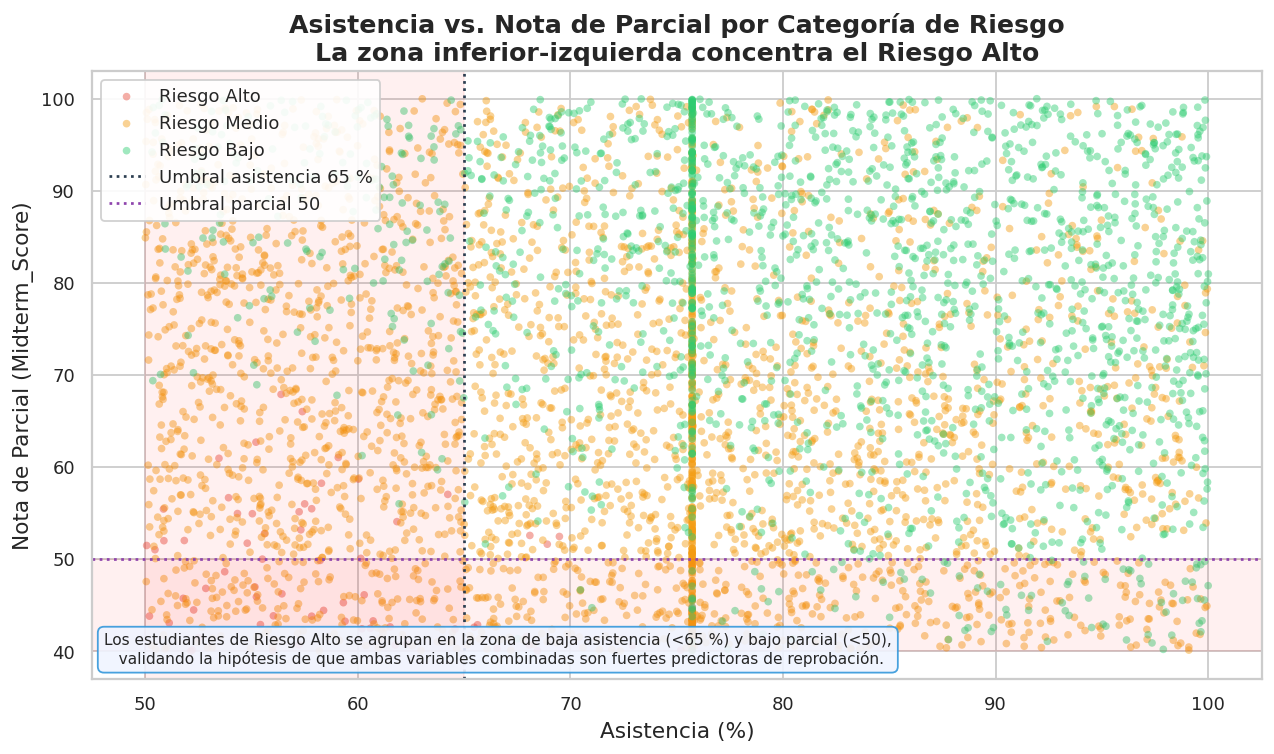

Gráfico 1.2 guardado.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for cat, color in PALETTE_RIESGO.items():
    subset = df[df['Categoria_Riesgo'] == cat]
    ax.scatter(subset['Attendance (%)'], subset['Midterm_Score'],
               c=color, label=f'Riesgo {cat}', alpha=0.45, s=18, edgecolors='none')

# Líneas de umbral de la hipótesis
ax.axvline(65, color='#2c3e50', linestyle=':', linewidth=1.5, label='Umbral asistencia 65 %')
ax.axhline(50, color='#8e44ad', linestyle=':', linewidth=1.5, label='Umbral parcial 50')

# Zona de peligro sombreada
ax.axvspan(df['Attendance (%)'].min(), 65, alpha=0.06, color='red')
ax.axhspan(df['Midterm_Score'].min(), 50, alpha=0.06, color='red')

ax.set_title('Asistencia vs. Nota de Parcial por Categoría de Riesgo\n'
             'La zona inferior-izquierda concentra el Riesgo Alto')
ax.set_xlabel('Asistencia (%)')
ax.set_ylabel('Nota de Parcial (Midterm_Score)')
ax.legend(loc='upper left', framealpha=0.9)

ax.text(0.01, 0.02,
    'Los estudiantes de Riesgo Alto se agrupan en la zona de baja asistencia (<65 %) y bajo parcial (<50),\n'
    '   validando la hipótesis de que ambas variables combinadas son fuertes predictoras de reprobación.',
    transform=ax.transAxes, fontsize=8.5, va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f4ff', edgecolor='#3498db', alpha=0.9))

plt.tight_layout()
plt.savefig('g1_2_scatter_asistencia_parcial.png', bbox_inches='tight')
plt.show()
print('Gráfico 1.2 guardado.')


#### Gráfico 1.3 — Tasa de Puntaje Bajo 60 (%) por Categoría de Riesgo y Nivel de Estrés


In [ ]:
# Agrupar estrés en tercios: Bajo / Medio / Alto
df['Estres_Cat'] = pd.cut(df['Stress_Level (1-10)'],
                           bins=[0, 3, 6, 10],
                           labels=['Estrés Bajo\n(1–3)', 'Estrés Medio\n(4–6)', 'Estrés Alto\n(7–10)'])

# Se usa Total_Score < 60 como criterio de bajo rendimiento real,
# ya que el campo Grade del dataset original no correlaciona con el puntaje calculado.
pivot = (df.groupby(['Categoria_Riesgo', 'Estres_Cat'], observed=True)
           .apply(lambda g: (g['Total_Score'] < 60).mean() * 100)
           .unstack('Estres_Cat'))

# Reordenar filas
pivot = pivot.reindex(['Bajo', 'Medio', 'Alto'])

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Estudiantes con Score < 60 (%)'}, ax=ax)

ax.set_title('Tasa de Score Bajo 60 (%) por Categoría de Riesgo y Nivel de Estrés\n'
             'Combinación crítica: Riesgo Alto + Estrés Alto')
ax.set_xlabel('Nivel de Estrés')
ax.set_ylabel('Categoría de Riesgo')

ax.text(0.01, -0.28,
    'La categoría de Riesgo Alto concentra la mayor proporción de estudiantes con puntaje bajo 60,\n'
    '   confirmando que el índice compuesto predice efectivamente el bajo rendimiento académico.',
    transform=ax.transAxes, fontsize=8.5, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff0f0', edgecolor='#e74c3c', alpha=0.9))

plt.tight_layout()
plt.savefig('g1_3_heatmap_score_bajo60.png', bbox_inches='tight')
plt.show()
print('Gráfico 1.3 guardado.')


---

### Pregunta 2 — Eficiencia del Esfuerzo Académico

> ¿Existe una relación no lineal entre horas de estudio y rendimiento? ¿En qué punto el incremento de horas deja de producir mejoras significativas?

**Hipótesis:** A partir de las 20 horas semanales el `Total_Score` se estabiliza; estudiantes con alto estrés no obtienen beneficio adicional.

#### Gráfico 2.1 — Horas de Estudio vs. Puntaje Total (con curva de tendencia LOWESS)

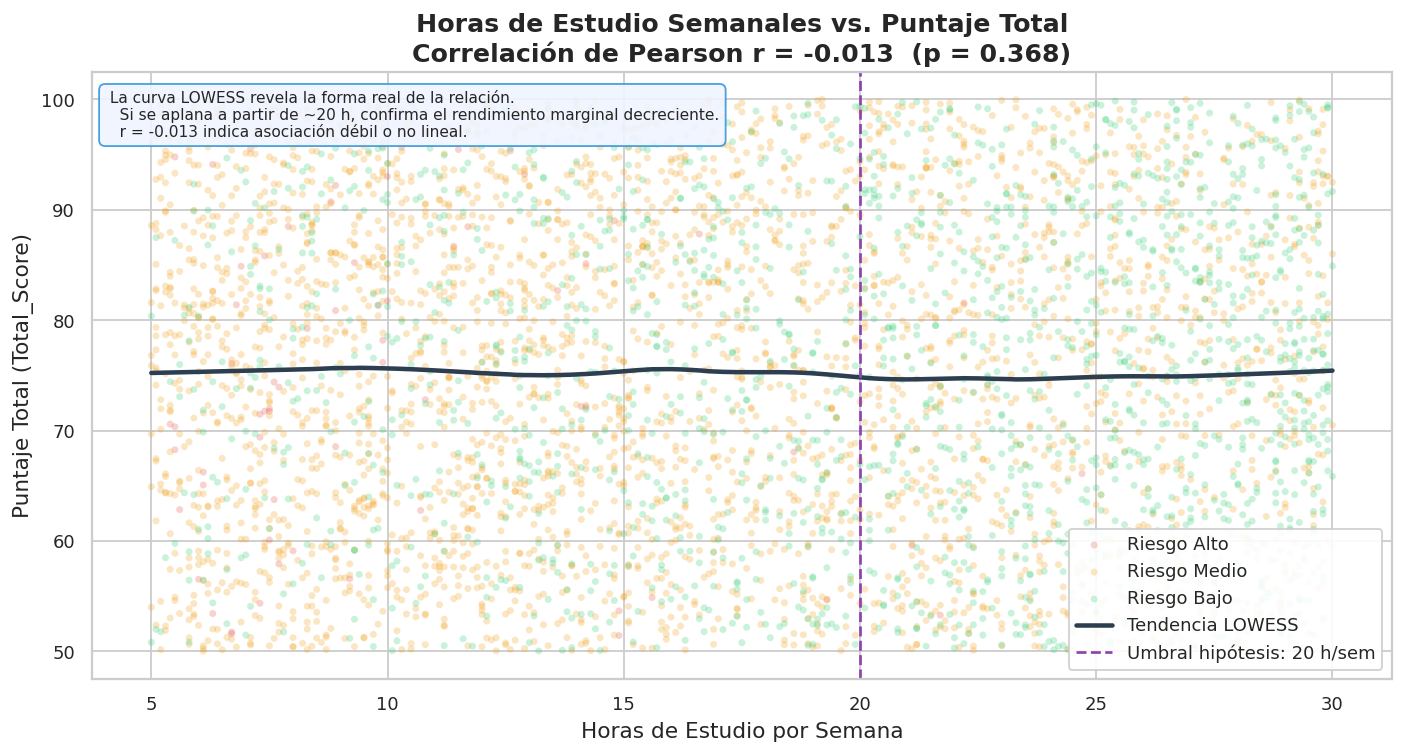

Gráfico 2.1 guardado.


In [ ]:
from scipy.stats import pearsonr

fig, ax = plt.subplots(figsize=(11, 6))

# Fondo por nivel de estrés
for cat, color in PALETTE_RIESGO.items():
    sub = df[df['Categoria_Riesgo'] == cat]
    ax.scatter(sub['Study_Hours_per_Week'], sub['Total_Score'],
               c=color, alpha=0.25, s=15, label=f'Riesgo {cat}', edgecolors='none')

# Curva LOWESS sobre todos los datos
from statsmodels.nonparametric.smoothers_lowess import lowess
sorted_data = df[['Study_Hours_per_Week','Total_Score']].dropna().sort_values('Study_Hours_per_Week')
smooth = lowess(sorted_data['Total_Score'], sorted_data['Study_Hours_per_Week'], frac=0.3)
ax.plot(smooth[:, 0], smooth[:, 1], color='#2c3e50', linewidth=2.5, label='Tendencia LOWESS')

# Línea de saturación hipotética (20 h)
ax.axvline(20, color='#8e44ad', linestyle='--', linewidth=1.5, label='Umbral hipótesis: 20 h/sem')

r, p = pearsonr(df['Study_Hours_per_Week'].dropna(), df['Total_Score'].dropna())
ax.set_title(f'Horas de Estudio Semanales vs. Puntaje Total\n'
             f'Correlación de Pearson r = {r:.3f}  (p {"< 0.001" if p < 0.001 else f"= {p:.3f}"})')
ax.set_xlabel('Horas de Estudio por Semana')
ax.set_ylabel('Puntaje Total (Total_Score)')
ax.legend(loc='lower right', framealpha=0.9)

ax.text(0.01, 0.97,
    f' La curva LOWESS revela la forma real de la relación.\n'
    f'   Si se aplana a partir de ~20 h, confirma el rendimiento marginal decreciente.\n'
    f'   r = {r:.3f} indica {"asociación positiva moderada" if 0.2 < abs(r) < 0.5 else "asociación débil o no lineal"}.',
    transform=ax.transAxes, fontsize=8.5, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f4ff', edgecolor='#3498db', alpha=0.9))

plt.tight_layout()
plt.savefig('g2_1_horas_vs_score_lowess.png', bbox_inches='tight')
plt.show()
print('Gráfico 2.1 guardado.')


#### Gráfico 2.2 — Eficiencia de Estudio por Categoría de Riesgo

/tmp/ipykernel_11010/3947513453.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Categoria_Riesgo', y='Eficiencia_Estudio',


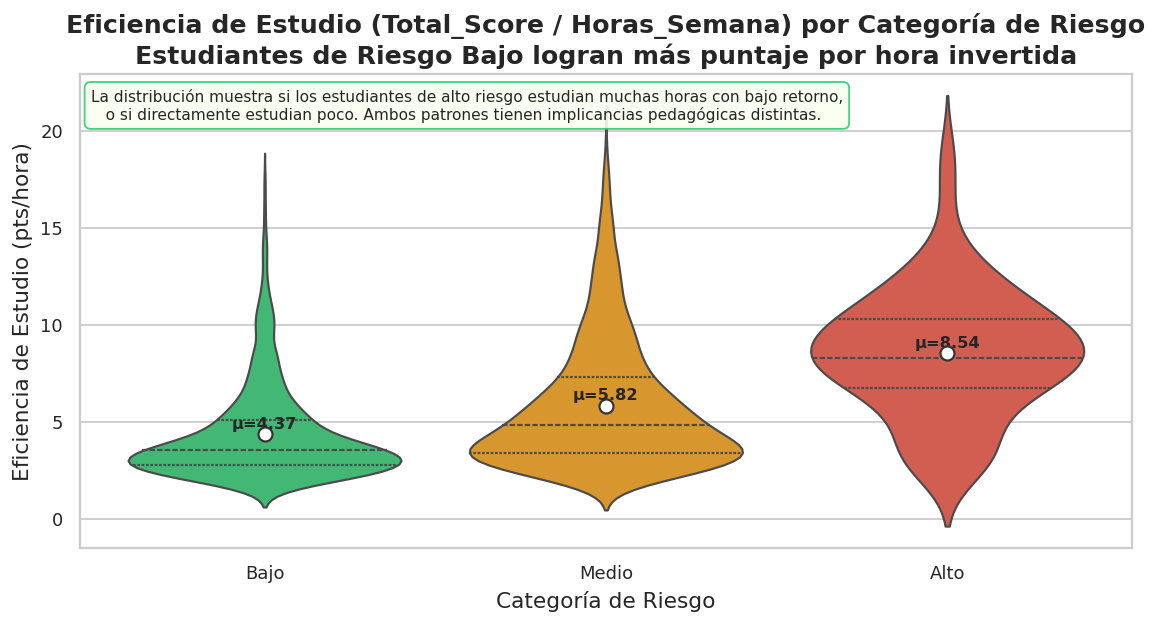

Gráfico 2.2 guardado.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

orden = ['Bajo', 'Medio', 'Alto']
colores = [PALETTE_RIESGO[c] for c in orden]

sns.violinplot(data=df, x='Categoria_Riesgo', y='Eficiencia_Estudio',
               order=orden, palette=PALETTE_RIESGO,
               inner='quartile', linewidth=1.2, ax=ax)

# Medias como puntos blancos
medias = df.groupby('Categoria_Riesgo')['Eficiencia_Estudio'].mean()
for i, cat in enumerate(orden):
    ax.scatter(i, medias[cat], color='white', s=60, zorder=5, edgecolors='#333333', linewidth=1.2)
    ax.text(i, medias[cat] + 0.15, f'μ={medias[cat]:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Eficiencia de Estudio (Total_Score / Horas_Semana) por Categoría de Riesgo\n'
             'Estudiantes de Riesgo Bajo logran más puntaje por hora invertida')
ax.set_xlabel('Categoría de Riesgo')
ax.set_ylabel('Eficiencia de Estudio (pts/hora)')

ax.text(0.01, 0.97,
    'La distribución muestra si los estudiantes de alto riesgo estudian muchas horas con bajo retorno,\n'
    '   o si directamente estudian poco. Ambos patrones tienen implicancias pedagógicas distintas.',
    transform=ax.transAxes, fontsize=8.5, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#f9fff0', edgecolor='#2ecc71', alpha=0.9))

plt.tight_layout()
plt.savefig('g2_2_eficiencia_violin.png', bbox_inches='tight')
plt.show()
print('Gráfico 2.2 guardado.')


#### Gráfico 2.3 — Total Score promedio por tramo de horas, separado por nivel de estrés

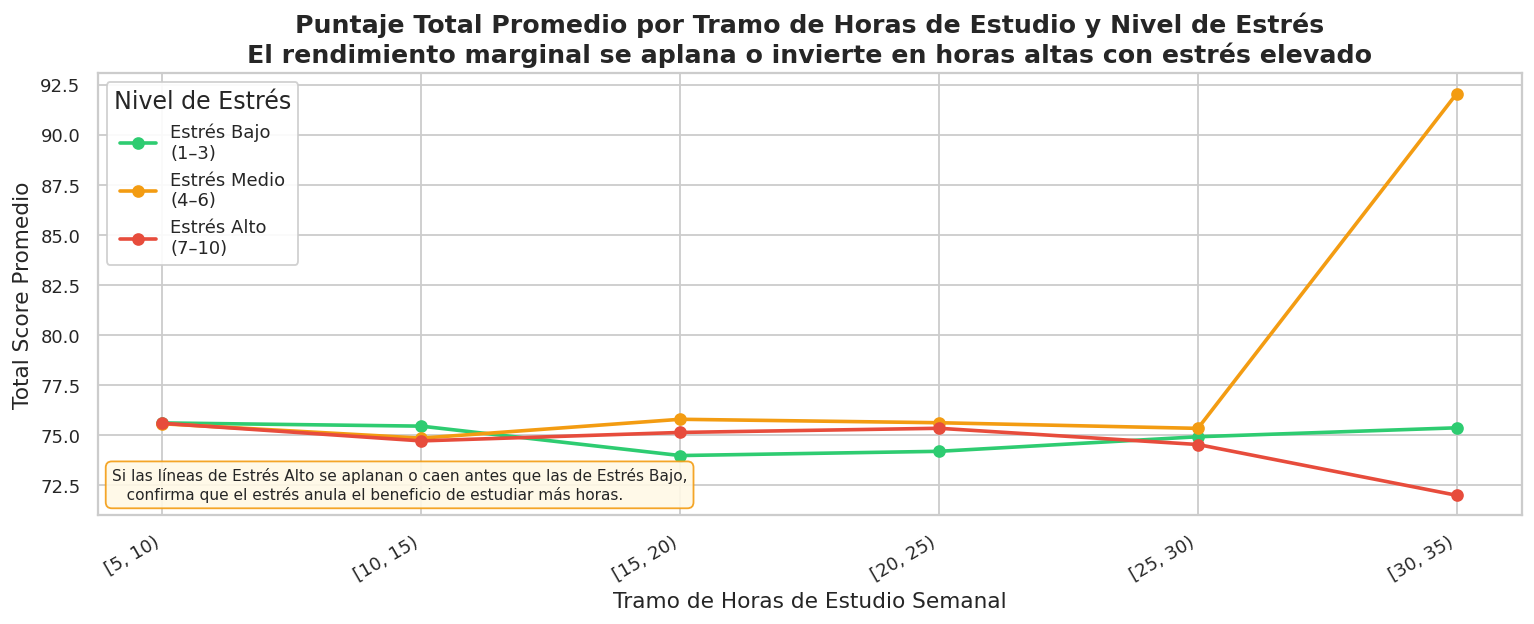

Gráfico 2.3 guardado.


In [ ]:
# Crear tramos de horas (bins de 5 h)
df['Tramo_Horas'] = pd.cut(df['Study_Hours_per_Week'],
                            bins=range(0, int(df['Study_Hours_per_Week'].max()) + 6, 5),
                            right=False)
df['Tramo_Horas_str'] = df['Tramo_Horas'].astype(str)

# Nivel de estrés agrupado
resumen = (df.groupby(['Tramo_Horas', 'Estres_Cat'], observed=True)['Total_Score']
             .mean().reset_index())
resumen['Tramo_str'] = resumen['Tramo_Horas'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))

colores_estres = {
    'Estrés Bajo\n(1–3)' : '#2ecc71',
    'Estrés Medio\n(4–6)': '#f39c12',
    'Estrés Alto\n(7–10)': '#e74c3c'
}

for estres_cat, grp in resumen.groupby('Estres_Cat', observed=True):
    grp_sorted = grp.sort_values('Tramo_Horas')
    ax.plot(grp_sorted['Tramo_str'], grp_sorted['Total_Score'],
            marker='o', linewidth=2, markersize=6,
            color=colores_estres.get(str(estres_cat), 'gray'),
            label=str(estres_cat))

ax.set_title('Puntaje Total Promedio por Tramo de Horas de Estudio y Nivel de Estrés\n'
             'El rendimiento marginal se aplana o invierte en horas altas con estrés elevado')
ax.set_xlabel('Tramo de Horas de Estudio Semanal')
ax.set_ylabel('Total Score Promedio')
ax.legend(title='Nivel de Estrés', framealpha=0.9)
plt.xticks(rotation=30, ha='right')

ax.text(0.01, 0.03,
    'Si las líneas de Estrés Alto se aplanan o caen antes que las de Estrés Bajo,\n'
    '   confirma que el estrés anula el beneficio de estudiar más horas.',
    transform=ax.transAxes, fontsize=8.5, va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff9e6', edgecolor='#f39c12', alpha=0.9))

plt.tight_layout()
plt.savefig('g2_3_score_por_horas_estres.png', bbox_inches='tight')
plt.show()
print('Gráfico 2.3 guardado.')


---

### Pregunta 3 — Brecha de Equidad por Contexto Socioeconómico

> ¿En qué medida el nivel de ingresos y el acceso a Internet condicionan el desempeño? ¿Qué departamentos presentan mayor dispersión?

**Hipótesis:** Estudiantes de bajos ingresos sin Internet muestran `Total_Score` significativamente inferior; la brecha es más pronunciada en departamentos con alta carga autónoma.

#### Gráfico 3.1 — Puntaje Promedio por Nivel de Ingresos y Acceso a Internet

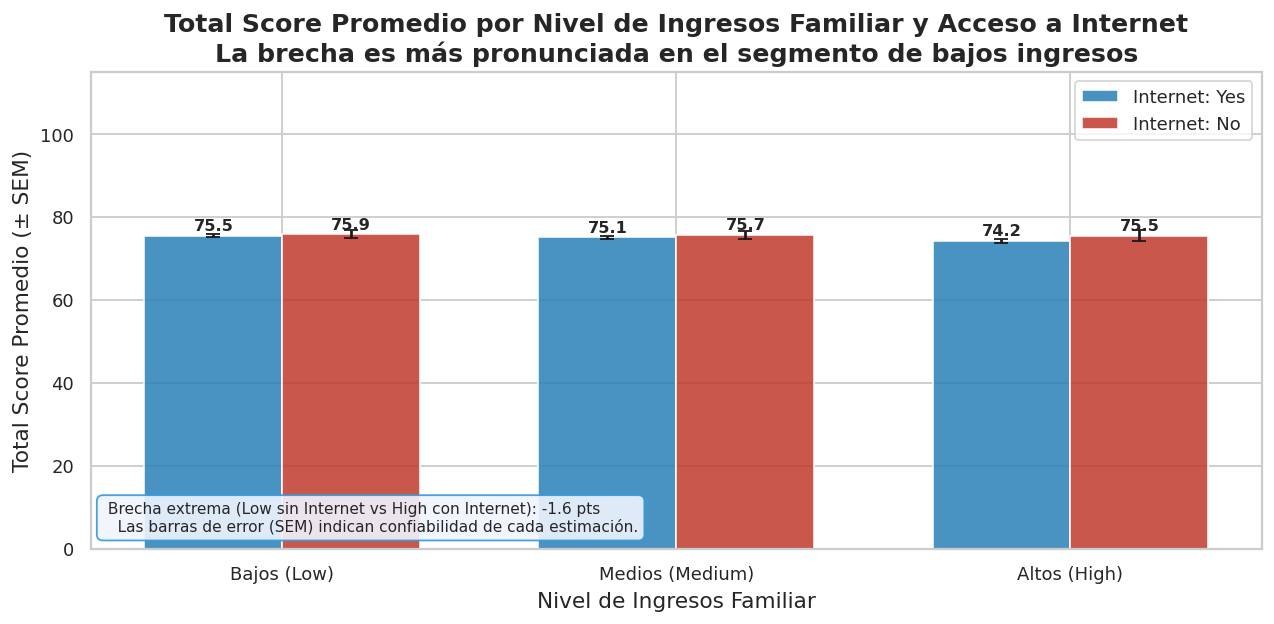

Gráfico 3.1 guardado.


In [ ]:
resumen_brecha = (df.groupby(['Family_Income_Level', 'Internet_Access_at_Home'], observed=True)['Total_Score']
                    .agg(['mean', 'sem'])
                    .reset_index())
resumen_brecha.columns = ['Ingresos', 'Internet', 'Media', 'SEM']

orden_ingresos = ['Low', 'Medium', 'High']
resumen_brecha['Ingresos'] = pd.Categorical(resumen_brecha['Ingresos'], categories=orden_ingresos, ordered=True)
resumen_brecha = resumen_brecha.sort_values('Ingresos')

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(orden_ingresos))
width = 0.35
internet_cats = resumen_brecha['Internet'].unique()
offsets = [-width/2, width/2]
colores_internet = {'Yes': '#2980b9', 'No': '#c0392b'}

for i, inet in enumerate(['Yes', 'No']):
    sub = resumen_brecha[resumen_brecha['Internet'] == inet].set_index('Ingresos').reindex(orden_ingresos)
    bars = ax.bar(x + offsets[i], sub['Media'], width=width,
                  color=colores_internet[inet], alpha=0.85,
                  label=f'Internet: {inet}', yerr=sub['SEM'], capsize=4)
    for bar, val in zip(bars, sub['Media']):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Total Score Promedio por Nivel de Ingresos Familiar y Acceso a Internet\n'
             'La brecha es más pronunciada en el segmento de bajos ingresos')
ax.set_xlabel('Nivel de Ingresos Familiar')
ax.set_ylabel('Total Score Promedio (± SEM)')
ax.set_xticks(x)
ax.set_xticklabels(['Bajos (Low)', 'Medios (Medium)', 'Altos (High)'])
ax.legend()
ax.set_ylim(0, df['Total_Score'].max() * 1.15)

# Calcular brecha Low sin internet vs High con internet
try:
    score_low_no  = resumen_brecha[(resumen_brecha['Ingresos']=='Low')  & (resumen_brecha['Internet']=='No')]['Media'].values[0]
    score_high_yes = resumen_brecha[(resumen_brecha['Ingresos']=='High') & (resumen_brecha['Internet']=='Yes')]['Media'].values[0]
    brecha = score_high_yes - score_low_no
    nota = f'Brecha extrema (Low sin Internet vs High con Internet): {brecha:.1f} pts'
except:
    nota = 'Ver valores en las barras para comparar brechas.'

ax.text(0.01, 0.03, f' {nota}\n   Las barras de error (SEM) indican confiabilidad de cada estimación.',
    transform=ax.transAxes, fontsize=8.5, va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f4ff', edgecolor='#3498db', alpha=0.9))

plt.tight_layout()
plt.savefig('g3_1_brecha_ingreso_internet.png', bbox_inches='tight')
plt.show()
print('Gráfico 3.1 guardado.')


#### Gráfico 3.2 — Dispersión de Puntaje por Departamento (ordenado por mediana)

/tmp/ipykernel_11010/2532275761.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Total_Score',


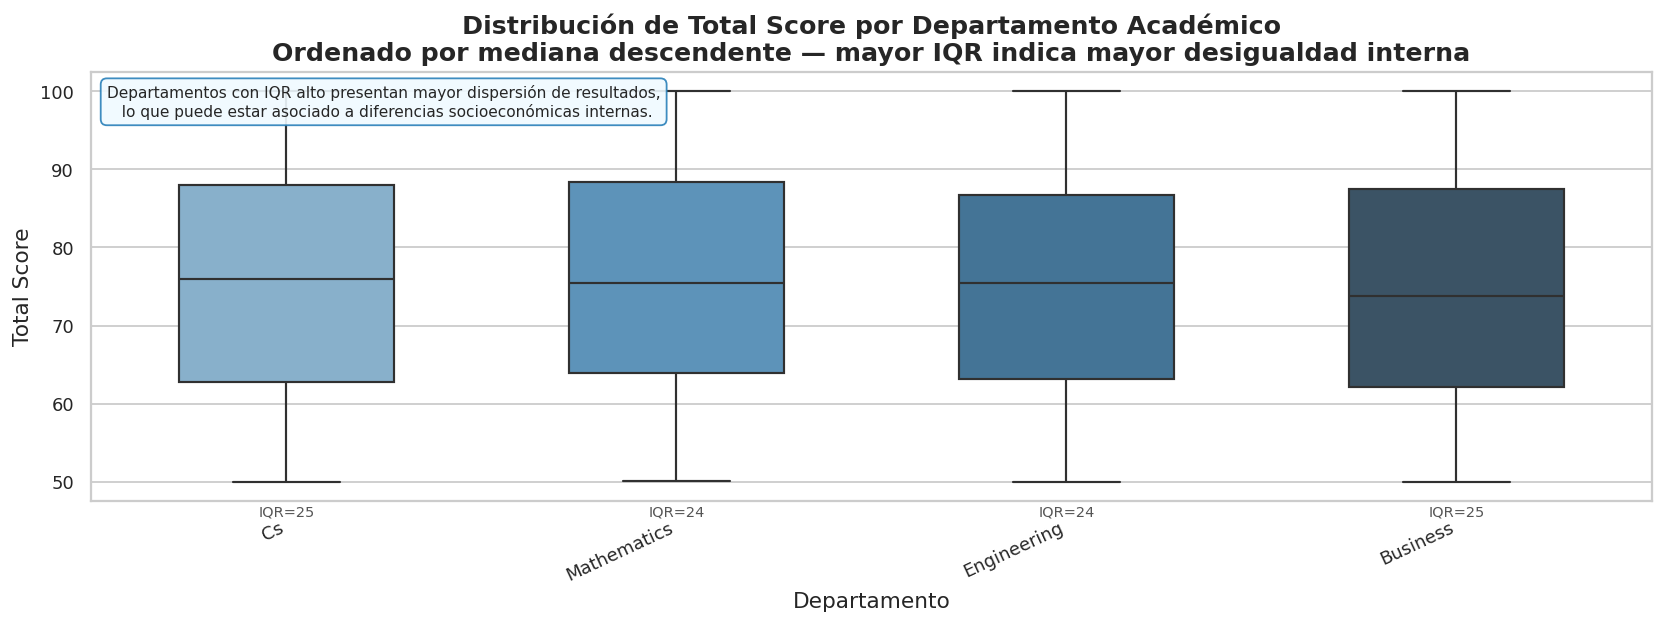

Gráfico 3.2 guardado.


In [ ]:
orden_dept = (df.groupby('Department')['Total_Score'].median()
                .sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(13, 5))

sns.boxplot(data=df, x='Department', y='Total_Score',
            order=orden_dept,
            palette='Blues_d',
            width=0.55, linewidth=1.2,
            flierprops=dict(marker='o', markersize=3, alpha=0.3),
            ax=ax)

# IQR de cada departamento como anotación
for i, dept in enumerate(orden_dept):
    sub = df[df['Department'] == dept]['Total_Score']
    iqr_val = sub.quantile(0.75) - sub.quantile(0.25)
    ax.text(i, sub.min() - 3, f'IQR={iqr_val:.0f}',
            ha='center', va='top', fontsize=8, color='#555555')

ax.set_title('Distribución de Total Score por Departamento Académico\n'
             'Ordenado por mediana descendente — mayor IQR indica mayor desigualdad interna')
ax.set_xlabel('Departamento')
ax.set_ylabel('Total Score')
plt.xticks(rotation=25, ha='right')

ax.text(0.01, 0.97,
    'Departamentos con IQR alto presentan mayor dispersión de resultados,\n'
    '   lo que puede estar asociado a diferencias socioeconómicas internas.',
    transform=ax.transAxes, fontsize=8.5, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0faff', edgecolor='#2980b9', alpha=0.9))

plt.tight_layout()
plt.savefig('g3_2_score_por_departamento.png', bbox_inches='tight')
plt.show()
print('Gráfico 3.2 guardado.')


#### Gráfico 3.3 — Mapa de Calor: Puntaje Promedio por Departamento y Nivel de Ingresos

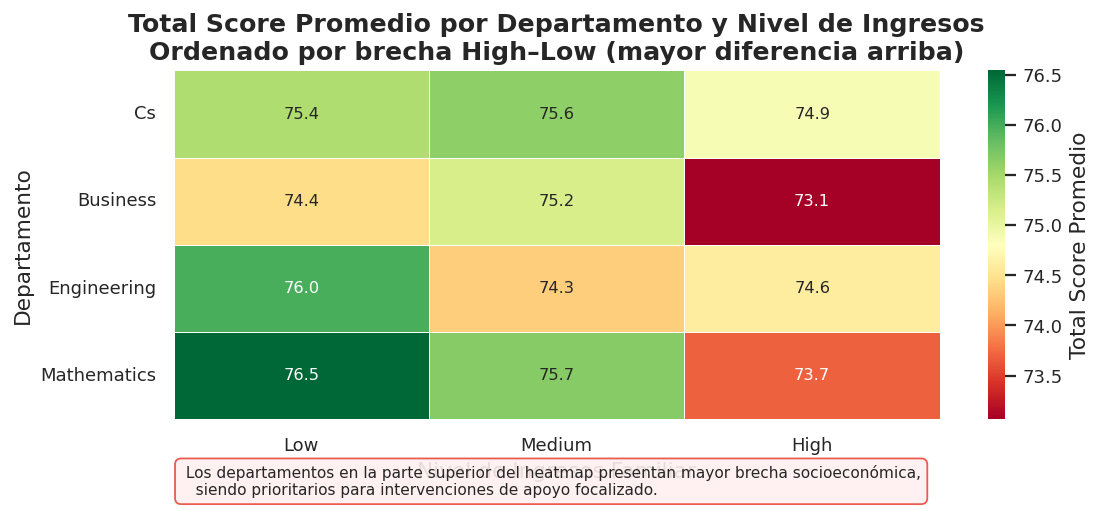

Gráfico 3.3 guardado.


In [ ]:
pivot_dept = (df.groupby(['Department', 'Family_Income_Level'], observed=True)['Total_Score']
                .mean().unstack('Family_Income_Level'))

# Ordenar columnas
cols_orden = [c for c in ['Low', 'Medium', 'High'] if c in pivot_dept.columns]
pivot_dept = pivot_dept[cols_orden]

# Ordenar filas por diferencia High - Low (mayor brecha arriba)
pivot_dept['_brecha'] = pivot_dept.get('High', 0) - pivot_dept.get('Low', 0)
pivot_dept = pivot_dept.sort_values('_brecha', ascending=False).drop(columns='_brecha')

fig, ax = plt.subplots(figsize=(9, len(pivot_dept) * 0.55 + 2))
sns.heatmap(pivot_dept, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 9},
            cbar_kws={'label': 'Total Score Promedio'}, ax=ax)

ax.set_title('Total Score Promedio por Departamento y Nivel de Ingresos\n'
             'Ordenado por brecha High–Low (mayor diferencia arriba)')
ax.set_xlabel('Nivel de Ingresos Familiar')
ax.set_ylabel('Departamento')

ax.text(0.01, -0.13,
    ' Los departamentos en la parte superior del heatmap presentan mayor brecha socioeconómica,\n'
    '   siendo prioritarios para intervenciones de apoyo focalizado.',
    transform=ax.transAxes, fontsize=8.5, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff0f0', edgecolor='#e74c3c', alpha=0.9))

plt.tight_layout()
plt.savefig('g3_3_heatmap_dept_ingreso.png', bbox_inches='tight')
plt.show()
print('Gráfico 3.3 guardado.')


---

### Paso 10 — Análisis Complementario: Mapa de Correlaciones

Matriz de correlación entre todas las variables numéricas del dataset limpio.  
Permite identificar relaciones no exploradas en las preguntas de negocio.

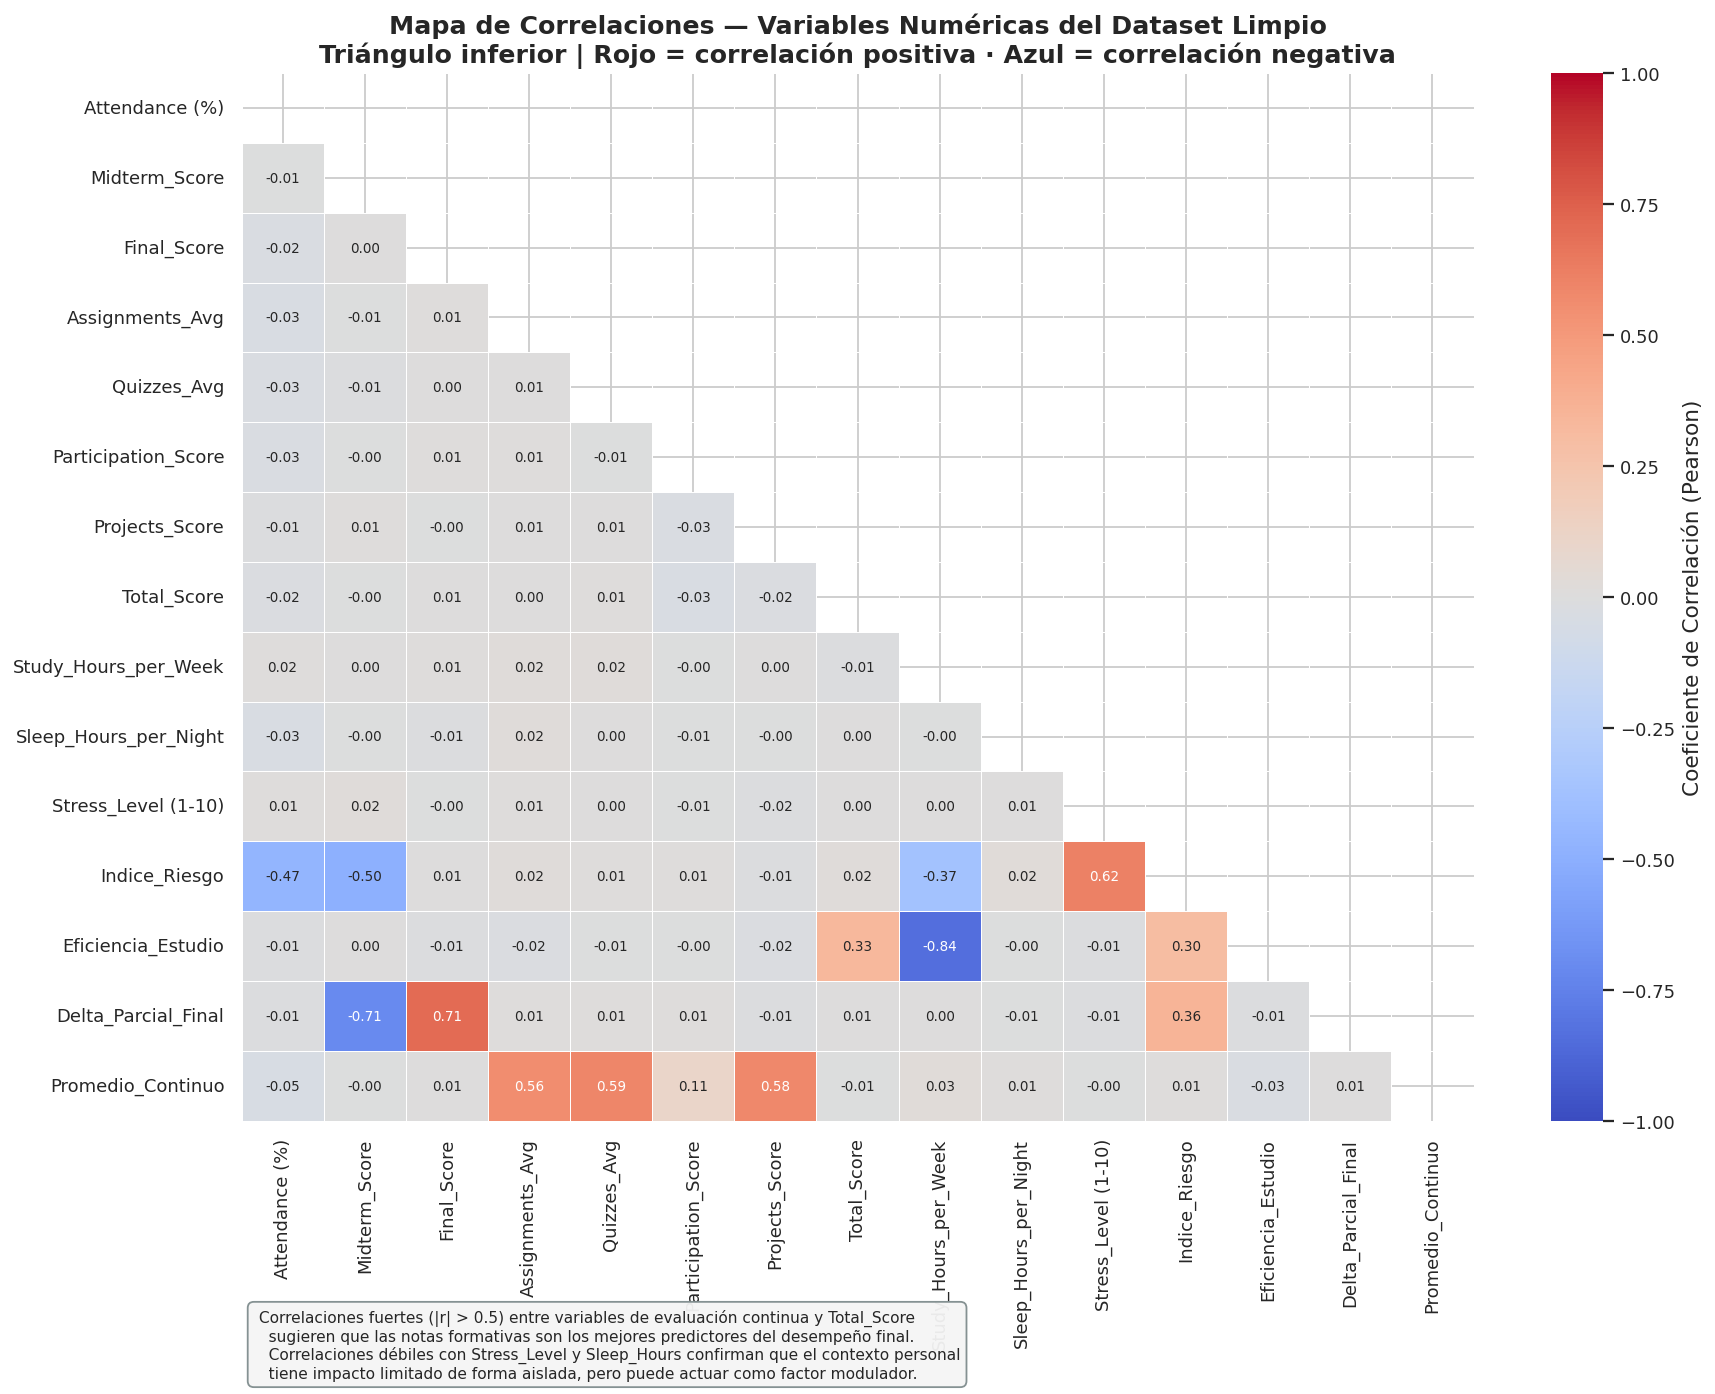

Gráfico de correlaciones guardado.


In [ ]:
cols_corr = [
    'Attendance (%)', 'Midterm_Score', 'Final_Score',
    'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
    'Projects_Score', 'Total_Score', 'Study_Hours_per_Week',
    'Sleep_Hours_per_Night', 'Stress_Level (1-10)',
    'Indice_Riesgo', 'Eficiencia_Estudio', 'Delta_Parcial_Final', 'Promedio_Continuo'
]

corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, linecolor='white',
            annot_kws={'size': 7.5},
            cbar_kws={'label': 'Coeficiente de Correlación (Pearson)'},
            ax=ax)

ax.set_title('Mapa de Correlaciones — Variables Numéricas del Dataset Limpio\n'
             'Triángulo inferior | Rojo = correlación positiva · Azul = correlación negativa')

ax.text(0.01, -0.18,
    ' Correlaciones fuertes (|r| > 0.5) entre variables de evaluación continua y Total_Score\n'
    '   sugieren que las notas formativas son los mejores predictores del desempeño final.\n'
    '   Correlaciones débiles con Stress_Level y Sleep_Hours confirman que el contexto personal\n'
    '   tiene impacto limitado de forma aislada, pero puede actuar como factor modulador.',
    transform=ax.transAxes, fontsize=8.5, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5', edgecolor='#7f8c8d', alpha=0.95))

plt.tight_layout()
plt.savefig('g4_correlaciones.png', bbox_inches='tight')
plt.show()
print('Gráfico de correlaciones guardado.')
